# Differentiable normalization of almost-linear lambda terms

Linear lambda terms are rooted trivalent maps over one generator — that is
Zeilberger's isomorphism, implemented by `closed.TermBase.to_map`. The
*almost-linear* fragment, where variables may be copied, encodes as rooted
maps with **two generators**: gamma (trivalent — abstraction `λ` and
application `@`) and delta (arbitrary arity — one node per copied variable
with one port per occurrence).

The geometry of interaction interprets such a map as a **token machine**
(Danos–Régnier, Mackie): a query travels from the root into the term carrying
two stacks — a *multiplicative* (gamma) stack recording the path through
`@`/`λ` nodes, and an *exponential* (delta) stack recording which copy of
each shared subterm it is in. Crossing a node through an auxiliary port
*pushes* a symbol on the corresponding stack; crossing through the principal
port *pops* one and routes accordingly. The principal ports are the function
port of `@`, the root port of `λ` and the binder port of `δ`, so that a beta
redex is a principal–principal cut.

This notebook relaxes the token machine into a neural network:

* stack symbols become $d$-dimensional vectors and stacks become
  fixed-capacity differentiable stacks — each wire of the map carries a
  **pair of sequences**, typed `Dim(Seq(d), Seq(d))`,
* routing becomes a softmax, so message passing (`CMap.pass_messages`,
  the execution formula) is differentiable end to end,
* one shared torch module drives all gamma nodes, one all delta nodes,
  and each *constant* gets its own module — its weights are the unknown:
  here the constants are **`plus` and `times` themselves**, and the only
  supervision is examples `plus(church(m))(church(n)) ↦ church(m + n)`.

Böhm-tree readback becomes decoding: a **root network** encodes the address
of a hole in a partially built Böhm tree on the gamma stack, message passing
returns the answer, and a readout classifies it into a Böhm-tree node — one
node per query, so decoding time is proportional to the depth of the normal
form and the loop halts iff the term normalizes. Ground truth comes from
syntactic head reduction, `closed.BohmTree`.

In [1]:
import random
import torch
from discopy.closed import (
    Abstraction, BohmTree, Unitype, Variable)
from discopy.neural import CMap, Dim, Network, Seq

torch.manual_seed(42)
D, L = 8, 16  # vector dimension and stack capacity
o = Unitype()

## Terms, maps and Böhm trees

Church numerals with addition and multiplication are almost-linear: with the
unitype `o`, which is its own exponential, they typecheck even though they
are not simply typed. Copying `f` in a numeral goes to one delta node with
one port per occurrence.

In [2]:
def church(n):
    def body(f):
        def inner(x):
            result = x
            for _ in range(n):
                result = f(result)
            return result
        return o(inner)
    return o(body)


add = o(lambda m: o(lambda n: o(lambda f: o(lambda x: m(f)(n(f)(x))))))
mult = o(lambda m: o(lambda n: o(lambda f: m(n(f)))))

sorted(box.name for box in church(3).to_map().boxes)

['@', '@', '@', 'δ', 'λ', 'λ']

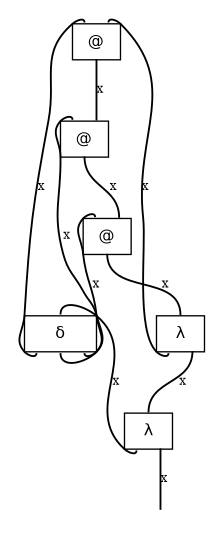

In [3]:
church(3).to_map().draw()

In [4]:
two, three = church(2), church(3)
assert BohmTree.from_term(add(two)(three)) == BohmTree.from_term(church(5))
assert BohmTree.from_term(mult(two)(three)) == BohmTree.from_term(church(6))

partial = BohmTree.from_term(mult(two)(three), budget=5)
partial  # the nodes not reached within the budget are holes

BohmTree(cod=closed.Unitype(cat.Ob('o')), variables=(closed.Variable('f', closed.Unitype(cat.Ob('o'))), closed.Variable('x', closed.Unitype(cat.Ob('o')))), head=0, args=(BohmTree(cod=closed.Unitype(cat.Ob('o')), variables=(), head=0, args=(BohmTree(cod=closed.Unitype(cat.Ob('o')), variables=(), head=0, args=(None,)),)),))

## The three shared networks

Differentiable stacks are `(Q, L, D)` tensors — `Q` parallel queries, depth
`L`, vectors of dimension `D`. Pushing shifts the rows down, popping reads
the top row and shifts up.

* **`GammaCore`** is shared by all `@` and `λ` boxes: it pops and pushes on
  the *gamma* stacks only — a token entering through an auxiliary port gets
  a `(kind, aux)` tag pushed, a token entering through the principal port
  has its head popped and soft-routed to the auxiliaries — while the delta
  stacks ride through untouched, scaled by the routing weights.
* **`DeltaCore`** is the exact dual, on the *delta* stacks, and must work
  for **any arity** with one set of weights: routing is attention over a
  table of index embeddings, so a delta with $n$ ports scores the popped
  head against the first $n$ indices.
* Each **constant** gets its own module answering queries on its single
  wire, with hidden width proportional to the number of generators in its
  type. It is a *convolution over the stack rows*: stack edits are local
  and shift-equivariant, the right inductive bias for behaviour that
  should not depend on how deep the query is.
* The **root network** turns hole addresses into queries and classifies
  the answers into Böhm-tree nodes ``(binders, head, arity)``. Its readout
  only sees the *top three rows* of the returned stacks: the answer must
  arrive at the top wherever the query started, matching the token
  machine where the address is consumed on arrival.
* `route` switches between softmax routing (training, differentiable) and
  one-hot routing (optionally at decode time, an actual token machine).

In [5]:
def push(stack, head):
    return torch.cat([head.unsqueeze(-2), stack[..., :-1, :]], dim=-2)


def pop(stack):
    zero = torch.zeros_like(stack[..., :1, :])
    return stack[..., 0, :], torch.cat([stack[..., 1:, :], zero], dim=-2)


def zeros(q=1):
    return torch.zeros(q, L, D)


HARD = [False]  # one-hot routing at decode time


def route(scores):
    # softmax during training, one-hot argmax when HARD
    weights = torch.softmax(scores, dim=-1)
    if HARD[0]:
        weights = torch.nn.functional.one_hot(
            weights.argmax(dim=-1), weights.shape[-1]).to(weights.dtype)
    return weights


class GammaCore(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.tags = torch.nn.Embedding(4, D)
        self.routers = torch.nn.ModuleList(
            [torch.nn.Linear(D, 2) for _ in range(2)])
        self.pop_transform = torch.nn.Linear(D, D)
        self.push_transform = torch.nn.Linear(D, D)


class DeltaCore(torch.nn.Module):
    def __init__(self, max_arity=8):
        super().__init__()
        self.tags = torch.nn.Embedding(max_arity, D)
        self.query = torch.nn.Linear(D, D)
        self.pop_transform = torch.nn.Linear(D, D)
        self.push_transform = torch.nn.Linear(D, D)

In [6]:
class GammaBox(torch.nn.Module):
    """One @ or λ box: wires (principal, aux0, aux1), kind 0 for @, 1 for λ.

    The box takes and returns one message per port in logical order, with
    wire w carried by the gamma port 2w and the delta port 2w + 1."""
    def __init__(self, core, kind, principal, auxes):
        super().__init__()
        self.core, self.kind = core, kind
        self.principal, self.auxes = principal, auxes

    def forward(self, *messages):
        def wire(w):
            return messages[2 * w], messages[2 * w + 1]

        q = next((m.shape[0] for m in messages if m is not None), 1)
        out = [None] * len(messages)
        g_p, d_p = wire(self.principal)
        if g_p is not None:  # pop the gamma head and route
            head, tail = pop(g_p)
            weights = route(self.core.routers[self.kind](head))
            content = torch.tanh(self.core.pop_transform(tail))
            for i, aux in enumerate(self.auxes):
                w = weights[:, i].reshape(-1, 1, 1)
                out[2 * aux] = w * content
                out[2 * aux + 1] = None if d_p is None else w * d_p
        g_out, d_out, any_aux = zeros(q), zeros(q), False
        for i, aux in enumerate(self.auxes):  # push the (kind, aux) tag
            g_a, d_a = wire(aux)
            if g_a is not None:
                any_aux = True
                tag = self.core.tags(torch.tensor(2 * self.kind + i))
                g_out = g_out + push(
                    torch.tanh(self.core.push_transform(g_a)),
                    tag.expand(g_a.shape[0], -1))
            if d_a is not None:
                any_aux, d_out = True, d_out + d_a
        if any_aux:
            out[2 * self.principal] = g_out
            out[2 * self.principal + 1] = d_out
        return out


class DeltaBox(torch.nn.Module):
    """One delta box of any arity; the principal is wire 0."""
    def __init__(self, core, arity):
        super().__init__()
        self.core, self.arity = core, arity

    def forward(self, *messages):
        def wire(w):
            return messages[2 * w], messages[2 * w + 1]

        q = next((m.shape[0] for m in messages if m is not None), 1)
        out = [None] * len(messages)
        keys = self.core.tags(torch.arange(self.arity))
        g_p, d_p = wire(0)
        if d_p is not None:  # pop the delta head, route by attention
            head, tail = pop(d_p)
            weights = route(torch.einsum(
                "qd,ad->qa", self.core.query(head), keys))
            content = torch.tanh(self.core.pop_transform(tail))
            for i in range(self.arity):
                w = weights[:, i].reshape(-1, 1, 1)
                out[2 * (1 + i) + 1] = w * content
                out[2 * (1 + i)] = None if g_p is None else w * g_p
        g_out, d_out, any_aux = zeros(q), zeros(q), False
        for i in range(self.arity):  # push the index embedding
            g_a, d_a = wire(1 + i)
            if d_a is not None:
                any_aux = True
                d_out = d_out + push(
                    torch.tanh(self.core.push_transform(d_a)),
                    keys[i].expand(d_a.shape[0], -1))
            if g_a is not None:
                any_aux, g_out = True, g_out + g_a
        if any_aux:
            out[0], out[1] = g_out, d_out
        return out

In [7]:
class ConstantModule(torch.nn.Module):
    def __init__(self, n_atoms=1, base_width=16):
        super().__init__()
        hidden = n_atoms * base_width
        self.net = torch.nn.Sequential(
            torch.nn.Conv1d(2 * D, hidden, 3, padding=1), torch.nn.Tanh(),
            torch.nn.Conv1d(hidden, hidden, 3, padding=1), torch.nn.Tanh(),
            torch.nn.Conv1d(hidden, 2 * D, 3, padding=1))

    def forward(self, gamma, delta):
        q = next((m.shape[0] for m in (gamma, delta) if m is not None), 1)
        gamma = zeros(q) if gamma is None else gamma
        delta = zeros(q) if delta is None else delta
        rows = torch.cat([gamma, delta], dim=-1).transpose(1, 2)
        result = self.net(rows).transpose(1, 2)
        return result[..., :D], result[..., D:]


class RootModule(torch.nn.Module):
    def __init__(self, n_classes, n_branches=1, hidden=64, k=3):
        super().__init__()
        self.symbols = torch.nn.Embedding(n_branches + 1, D)
        self.stop, self.k = n_branches, k
        self.readout = torch.nn.Sequential(
            torch.nn.Linear(2 * self.k * D, hidden), torch.nn.Tanh(),
            torch.nn.Linear(hidden, n_classes))

    def query(self, addresses):
        gamma = zeros(len(addresses))
        for q, address in enumerate(addresses):
            for j, branch in enumerate(address):
                gamma[q, j] = self.symbols(torch.tensor(branch))
            gamma[q, len(address)] = self.symbols(torch.tensor(self.stop))
        return gamma, zeros(len(addresses))

    def classify(self, gamma, delta):
        q = gamma.shape[0]
        flat = torch.cat([gamma[:, :self.k].reshape(q, -1),
                          delta[:, :self.k].reshape(q, -1)], dim=-1)
        return self.readout(flat)

The functor from term maps to neural maps doubles every wire into two
self-dual `Seq(D)` atoms — the gamma stack and the delta stack are separate
ports, so the two-stack structure lives in the types and every message is a
single tensor.

In [8]:
def to_networks(cmap, gamma_core, delta_core, constants):
    boxes = []
    for box in cmap.boxes:
        if box.name == "@":
            module = GammaBox(gamma_core, 0, principal=0, auxes=(2, 1))
        elif box.name == "λ":
            module = GammaBox(gamma_core, 1, principal=1, auxes=(0, 2))
        elif box.name == "δ":
            module = DeltaBox(delta_core, arity=len(box.cod))
        else:
            module = constants[box.name]
        boxes.append(Network(
            box.name, Dim(*(2 * len(box.dom)) * (Seq(D), )),
            Dim(*(2 * len(box.cod)) * (Seq(D), )), module=module))
    edges = [None] * (2 * cmap.n_ports)
    for i, j in enumerate(cmap.edges):
        edges[2 * i], edges[2 * i + 1] = 2 * j, 2 * j + 1
    return CMap(
        Dim(*(2 * len(cmap.dom)) * (Seq(D), )),
        Dim(*(2 * len(cmap.cod)) * (Seq(D), )), tuple(boxes), edges)


def answer(nmap, root, addresses, n_rounds=None):
    """Send one query per address into the root, classify what comes back."""
    gamma, delta = root.query(addresses)
    g_port, d_port = nmap.n_ports - 2, nmap.n_ports - 1
    messages = nmap.pass_messages(
        init={nmap.edges[g_port]: gamma, nmap.edges[d_port]: delta},
        n_rounds=n_rounds)
    g_in = messages[g_port] if messages[g_port] is not None\
        else zeros(len(addresses))
    d_in = messages[d_port] if messages[d_port] is not None\
        else zeros(len(addresses))
    return root.classify(g_in, d_in)

## The dataset: train small, test bigger

Two parts, as one synthetic dataset of almost-linear terms with their
normal forms:

1. **naive random linear lambda terms** — sampled by recursively splitting
   the free variables between function and argument;
2. **addition and multiplication, learned from examples** — the constants
   `plus` and `times` are *unknown*: their boxes carry their own weights and
   the only supervision is input-output examples
   `plus(church(m))(church(n)) ↦ church(m + n)` for all pairs with
   `m + n ≤ 4`, and `times` likewise for `m · n ≤ 4`. The network must
   invent, inside one box, the token-passing behaviour that the lambda term
   `λm.λn.λf.λx. m(f)(n(f)(x))` would have.

The test set only contains pairs whose results are *strictly larger than
anything seen in training*: sums and products of 5 and 6 — extrapolation,
not interpolation.

In [9]:
def random_linear_term(size, rng, retries=100):
    """A random closed linear lambda term with ``size`` internal nodes."""
    counter = [0]

    def fresh():
        counter[0] += 1
        return Variable(f"v{counter[0]}", o)

    def sample(size, free):
        if size == 0:
            return free[0] if len(free) == 1 else None
        if not free or rng.random() < 0.45:
            var = fresh()
            body = sample(size - 1, free + [var])
            return None if body is None else Abstraction(var, body)
        rng.shuffle(free)
        cut = rng.randint(0, len(free))
        split = rng.randint(0, size - 1)
        func = sample(split, free[:cut])
        if func is None:
            return None
        args = sample(size - split - 1, free[cut:])
        return None if args is None else func(args)

    for _ in range(retries):
        term = sample(size, [])
        if term is not None:
            return term
    raise ValueError(f"Could not sample a linear term of size {size}.")


rng = random.Random(0)
random_terms, seen = [], set()
while len(random_terms) < 4:
    term = random_linear_term(2 * rng.randint(1, 3) + 1, rng)
    tree = BohmTree.from_term(term)
    if tree not in seen:
        seen.add(tree)
        random_terms.append((term, tree))
for term, _ in random_terms[:3]:
    print(term)

o(lambda v1: v1(o(lambda v2: o(lambda v3: v2(v3)))))
o(lambda v28: v28(o(lambda v29: v29))(o(lambda v30: v30)))
o(lambda v57: o(lambda v58: v58(o(lambda v59: v59)))(v57))


In [10]:
plus, times = o("plus"), o("times")

train_pairs = {
    "plus": [(m, n) for m in range(1, 4) for n in range(1, 4) if m + n <= 4],
    "times": [(m, n) for m in range(1, 5) for n in range(1, 5)
              if m * n <= 4]}
test_pairs = {
    "plus": [(2, 3), (3, 2), (4, 1), (3, 3)],   # sums 5, 5, 5, 6
    "times": [(2, 3), (3, 2)]}                   # products 6
operations = {
    "plus": (plus, lambda m, n: m + n),
    "times": (times, lambda m, n: m * n)}


def instance(name, m, n):
    constant, value = operations[name]
    return (constant(church(m))(church(n)).to_map(),
            BohmTree.from_term(church(value(m, n))))


train_maps = {(name, m, n): instance(name, m, n)
              for name, pairs in train_pairs.items() for m, n in pairs}
len(train_maps), train_pairs

(14,
 {'plus': [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (3, 1)],
  'times': [(1, 1), (1, 2), (1, 3), (1, 4), (2, 1), (2, 2), (3, 1), (4, 1)]})

## Training

Queries only depend on their address, so all the nodes of one target train
in parallel along the leading `Q` dimension: one `pass_messages` per map per
step, teacher-forced cross-entropy on the Böhm-tree node classes. The same
`plus` module appears in every map that mentions it, so it is trained in
six different contexts at once.

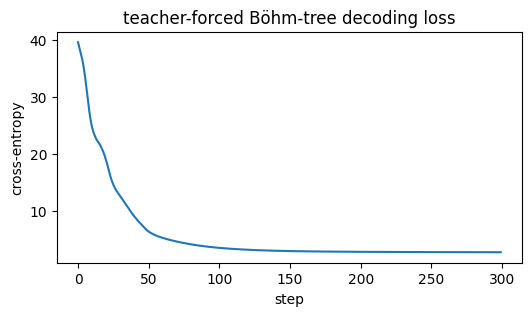

In [11]:
def tree_addresses(tree, address=()):
    result = [(address, tree)]
    for i, arg in enumerate(tree.args):
        result += tree_addresses(arg, address + (i, ))
    return result


def node_class(node):
    return (len(node.variables), node.head, len(node.args))


all_trees = [tree for _, tree in train_maps.values()]\
    + [tree for _, tree in random_terms] + [BohmTree.from_term(church(6))]
classes = sorted({node_class(n) for t in all_trees
                  for _, n in tree_addresses(t)})
class_index = {c: i for i, c in enumerate(classes)}
n_branches = max(len(n.args) for t in all_trees
                 for _, n in tree_addresses(t))

gamma_core, delta_core = GammaCore(), DeltaCore()
constants = {"plus": ConstantModule(n_atoms=3),
             "times": ConstantModule(n_atoms=3)}
root = RootModule(n_classes=len(classes), n_branches=n_branches)

nmaps = {key: to_networks(cmap, gamma_core, delta_core, constants)
         for key, (cmap, _) in train_maps.items()}
random_nmaps = [
    (to_networks(term.to_map(), gamma_core, delta_core, constants), tree)
    for term, tree in random_terms]


def addresses_and_labels(tree):
    pairs = tree_addresses(tree)
    return ([address for address, _ in pairs],
            torch.tensor([class_index[node_class(n)] for _, n in pairs]))


data = [(nmaps[key], *addresses_and_labels(tree))
        for key, (_, tree) in train_maps.items()] + [
    (nmap, *addresses_and_labels(tree)) for nmap, tree in random_nmaps]

parameters = [*gamma_core.parameters(), *delta_core.parameters(),
              *root.parameters()]
for module in constants.values():
    parameters += list(module.parameters())
optimizer = torch.optim.Adam(parameters, lr=3e-3)

losses = []
for step in range(300):
    optimizer.zero_grad()
    loss = 0
    for nmap, addresses, labels in data:
        logits = answer(nmap, root, addresses)
        loss = loss + torch.nn.functional.cross_entropy(logits, labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("step"), plt.ylabel("cross-entropy")
plt.title("teacher-forced Böhm-tree decoding loss")
plt.show()

## The learned addition and multiplication tables

One query per hole, leftmost-outermost, until the tree is complete: the
number of queries is the size of the normal form and their depth is its
depth — the loop halts iff the decoded tree does.

In [12]:
def decode(nmap, root, max_nodes=25):
    holes, nodes = [()], {}
    while holes and len(nodes) < max_nodes:
        address = holes.pop(0)
        if len(address) >= L - 1:  # deeper queries do not fit the stack
            nodes[address] = None
            continue
        with torch.no_grad():
            logits = answer(nmap, root, [address])
        nodes[address] = classes[int(logits[0].argmax())]
        holes += [address + (i, ) for i in range(nodes[address][2])]
    return nodes


def tree_to_nodes(tree):
    return {address: node_class(n)
            for address, n in tree_addresses(tree)}


def value_of(nodes):
    """The numeral decoded, i.e. its number of successor nodes."""
    return sum(node is not None and node[1:] == (0, 1)
               for node in nodes.values())


for (name, m, n) in train_maps:
    got = value_of(decode(nmaps[(name, m, n)], root))
    true = operations[name][1](m, n)
    print(f"{name}({m}, {n}) -> {got} (true {true})"
          + ("" if got == true else "  MISS"))

exact = sum(decode(nmap, root) == tree_to_nodes(tree)
            for nmap, tree in random_nmaps)
print(f"random linear terms decoded exactly: {exact}/{len(random_nmaps)}")

plus(1, 1) -> 2 (true 2)
plus(1, 2) -> 3 (true 3)


plus(1, 3) -> 4 (true 4)
plus(2, 1) -> 3 (true 3)


plus(2, 2) -> 4 (true 4)


plus(3, 1) -> 4 (true 4)
times(1, 1) -> 1 (true 1)
times(1, 2) -> 2 (true 2)


times(1, 3) -> 3 (true 3)


times(1, 4) -> 4 (true 4)
times(2, 1) -> 2 (true 2)


times(2, 2) -> 4 (true 4)
times(3, 1) -> 3 (true 3)


times(4, 1) -> 4 (true 4)
random linear terms decoded exactly: 2/4


## Extrapolation: sums bigger than anything seen in training

The headline test — and, honestly, where this pilot stops. The learned
boxes reproduce the training tables exactly, but on pairs whose results
exceed everything seen in training the decoded values clamp near the
training maximum: the system solved the training set as classification
rather than by learning depth-generalizing token dynamics.

In [13]:
for name, pairs in test_pairs.items():
    for m, n in pairs:
        cmap, tree = instance(name, m, n)
        nmap = to_networks(cmap, gamma_core, delta_core, constants)
        got = value_of(decode(nmap, root))
        true = operations[name][1](m, n)
        print(f"{name}({m}, {n}) -> {got} (true {true})"
              + ("" if got == true else "  MISS"))

plus(2, 3) -> 3 (true 5)  MISS


plus(3, 2) -> 4 (true 5)  MISS


plus(4, 1) -> 4 (true 5)  MISS


plus(3, 3) -> 4 (true 6)  MISS


times(2, 3) -> 4 (true 6)  MISS


times(3, 2) -> 4 (true 6)  MISS


In [14]:
# The same tables with one-hot routing: the trained weights read as an
# actual token machine rather than a superposition of paths.
HARD[0] = True
hits = sum(value_of(decode(nmaps[key], root))
           == operations[key[0]][1](*key[1:]) for key in train_maps)
print(f"training tables with hard routing: {hits}/{len(train_maps)}")
for name, pairs in test_pairs.items():
    for m, n in pairs:
        cmap, _ = instance(name, m, n)
        nmap = to_networks(cmap, gamma_core, delta_core, constants)
        got = value_of(decode(nmap, root))
        print(f"{name}({m}, {n}) -> {got}"
              f" (true {operations[name][1](m, n)})")
HARD[0] = False

training tables with hard routing: 13/14


plus(2, 3) -> 3 (true 5)


plus(3, 2) -> 4 (true 5)


plus(4, 1) -> 4 (true 5)


plus(3, 3) -> 4 (true 6)


times(2, 3) -> 4 (true 6)


times(3, 2) -> 4 (true 6)


## Where to go from here

The system learns the full addition and multiplication tables it is
trained on, from input-output examples alone, through nothing but
differentiable message passing on the maps of almost-linear lambda terms —
the constants `plus` and `times` are single boxes whose weights must
reproduce the behaviour of four-binder lambda terms, shared across all the
examples that mention them.

The extrapolation tables delimit the pilot: depth generalization — decoding
sums strictly larger than anything seen in training — does not emerge at
this scale, even with the shift-equivariant readout and constants and with
hard routing at decode time. This is the classical length-generalization
problem, and the natural next steps are structural: train across many more
operations and term shapes so that classification shortcuts stop paying
off, curriculum over target sizes, and a consistency objective tying the
token language at every wire to the one at the root — making the learned
geometry of interaction context-free.

Everything is generic: `to_networks` turns *any* almost-linear term into a
trainable token machine, `pass_messages` runs the execution formula over
arbitrary messages, and the same three shared networks transfer across all
term graphs — string diagrams as neural architectures, with the geometry
of interaction as their operational semantics.